In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Multiple Linear Regression — OJ Dataset (ISLR/ISLP)
====================================================

Description:
    Demonstrates multiple linear regression using the OJ dataset from the
    ISLR/ISLP library. Covers four model configurations:
      Example 1: Numeric + categorical (factor) predictors, with intercept
      Example 2: Numeric + categorical predictors, without intercept
      Example 3: Numeric predictors only, with intercept
      Example 4: Numeric predictors only, without intercept

    For each model: fit on train set, diagnostic plots, ANOVA-style table,
    predictions on test set, RMSE and R-squared performance metrics.
    Also demonstrates how to extract model attributes: coefficients,
    standard errors, confidence intervals, degrees of freedom.

    R equivalent: multiple_linear_regression_ISLR_OJ.Rmd
    R libraries:  ISLR, ggplot2, psych, MASS, dplyr, DAAG
    Python libs:  ISLP, pandas, numpy, matplotlib, seaborn, statsmodels, sklearn

Dataset:
    OJ {ISLR/ISLP} — Orange Juice purchase data
    1070 observations, 18 variables
    Response variable: PriceCH (Price of Citrus Hill OJ)

Revision History:
    2025-01-01  Original R development (Harvard STAT 109, 2023)
                - R script: multiple_linear_regression_ISLR_OJ.Rmd

    2026-04-03  Converted to Python / Jupyter Notebook
                - Replaced lm() with statsmodels OLS
                - Replaced ggplot2 with matplotlib + seaborn
                - Replaced pairs.panels() with seaborn pairplot
                - Replaced ISLR::OJ with ISLP.load_data('OJ')
                - Added sklearn metrics for RMSE and R-squared
"""

"\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nMultiple Linear Regression — OJ Dataset (ISLR/ISLP)\n====================================================\n\nDescription:\n    Demonstrates multiple linear regression using the OJ dataset from the\n    ISLR/ISLP library. Covers four model configurations:\n      Example 1: Numeric + categorical (factor) predictors, with intercept\n      Example 2: Numeric + categorical predictors, without intercept\n      Example 3: Numeric predictors only, with intercept\n      Example 4: Numeric predictors only, without intercept\n\n    For each model: fit on train set, diagnostic plots, ANOVA-style table,\n    predictions on test set, RMSE and R-squared performance metrics.\n    Also demonstrates how to ex

# Multiple Linear Regression — OJ Dataset (ISLR/ISLP)

## Objectives

Demonstrate multiple linear regression using the **OJ dataset** from the ISLP library.

Four model configurations are explored:

- **Example 1:** Numeric + categorical predictors, **with** intercept
- **Example 2:** Numeric + categorical predictors, **without** intercept
- **Example 3:** Numeric predictors only, **with** intercept
- **Example 4:** Numeric predictors only, **without** intercept

For each model:
- Fit on train set
- Diagnostic residual plots
- ANOVA-style table
- Predictions on test set
- RMSE and R² performance metrics

Also demonstrates: extracting coefficients, standard errors, confidence intervals, and degrees of freedom.

**R equivalent:** `multiple_linear_regression_ISLR_OJ.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling — mirrors R's lm() and summary()
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Machine learning — train/test split, metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

# ISLP — official dataset companion to ISL with Python
from ISLP import load_data

# Scipy — t-distribution (mirrors R's qt())
from scipy.stats import t as t_dist

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

print('Imports complete.')

Imports complete.


## Dataset: OJ {ISLR/ISLP}

The **OJ** dataset contains 1070 purchases where the customer either purchased Citrus Hill (CH)
or Minute Maid (MM) orange juice. 18 variables describe price, discount, store, and loyalty metrics.

**Response variable:** `PriceCH` — Price of Citrus Hill OJ (USD)

**Key predictors used:**
- `PriceMM` — Price of Minute Maid OJ
- `WeekofPurchase` — Week number of the purchase
- `DiscCH` — Discount offered on CH
- `Store7` — Whether the store is Store 7 (categorical: Yes/No)
- `STORE` — Store identifier (numeric)

In [3]:
# Load OJ dataset — mirrors R: data(OJ, package='ISLR')
OJ = load_data('OJ')

# Structure — mirrors R: str(OJ)
print(f'Shape: {OJ.shape}')   # 1070 observations, 18 variables
print()
print(OJ.dtypes)
print()
OJ.head()

Shape: (1070, 18)

Purchase          category
WeekofPurchase       int64
StoreID              int64
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH            int64
SpecialMM            int64
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE                int64
dtype: object



,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


**Note:** There are 1070 observations. This will be needed for degrees of freedom calculations downstream.

Note that `Store7` is loaded as an object (string) column with values `'Yes'`/`'No'`.
This mirrors R's factor variable. `statsmodels` formula API will handle it as a categorical
automatically via `C(Store7)` notation.

### Exploratory Plot: PriceCH vs. PriceMM by Store7

Mirrors R: `OJ %>% ggplot(aes(x=PriceCH, y=PriceMM, col=Store7)) + geom_point() + geom_smooth(method='lm')`

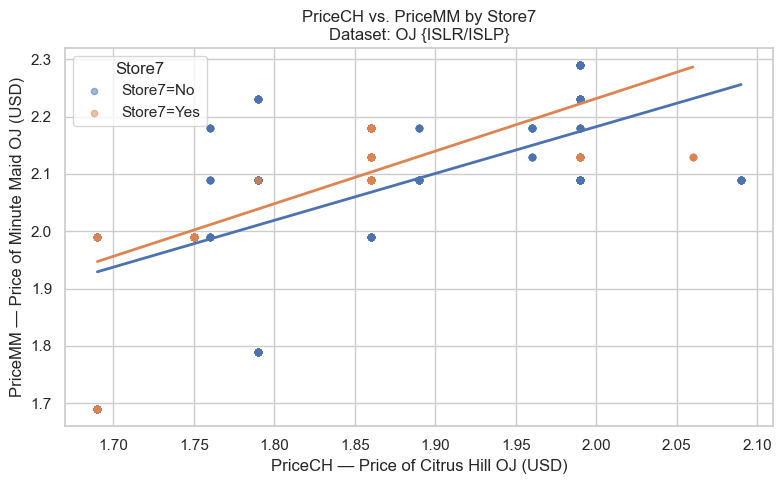

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot colored by Store7 — mirrors ggplot col=Store7
for label, group in OJ.groupby('Store7', observed=True):
    ax.scatter(group['PriceCH'], group['PriceMM'],
               label=f'Store7={label}', alpha=0.5, s=20)

    # Regression line per group — mirrors geom_smooth(method='lm')
    m_fit = np.polyfit(group['PriceCH'], group['PriceMM'], 1)
    x_line = np.linspace(group['PriceCH'].min(), group['PriceCH'].max(), 100)
    ax.plot(x_line, np.polyval(m_fit, x_line), linewidth=2)

ax.set_xlabel('PriceCH — Price of Citrus Hill OJ (USD)')
ax.set_ylabel('PriceMM — Price of Minute Maid OJ (USD)')
ax.set_title('PriceCH vs. PriceMM by Store7\nDataset: OJ {ISLR/ISLP}')
ax.legend(title='Store7')
plt.tight_layout()
plt.show()

### Pairs Plot — Selected Variables

Mirrors R: `pairs.panels()` from the `psych` package.
Python equivalent: `seaborn.pairplot()` with correlation annotations.

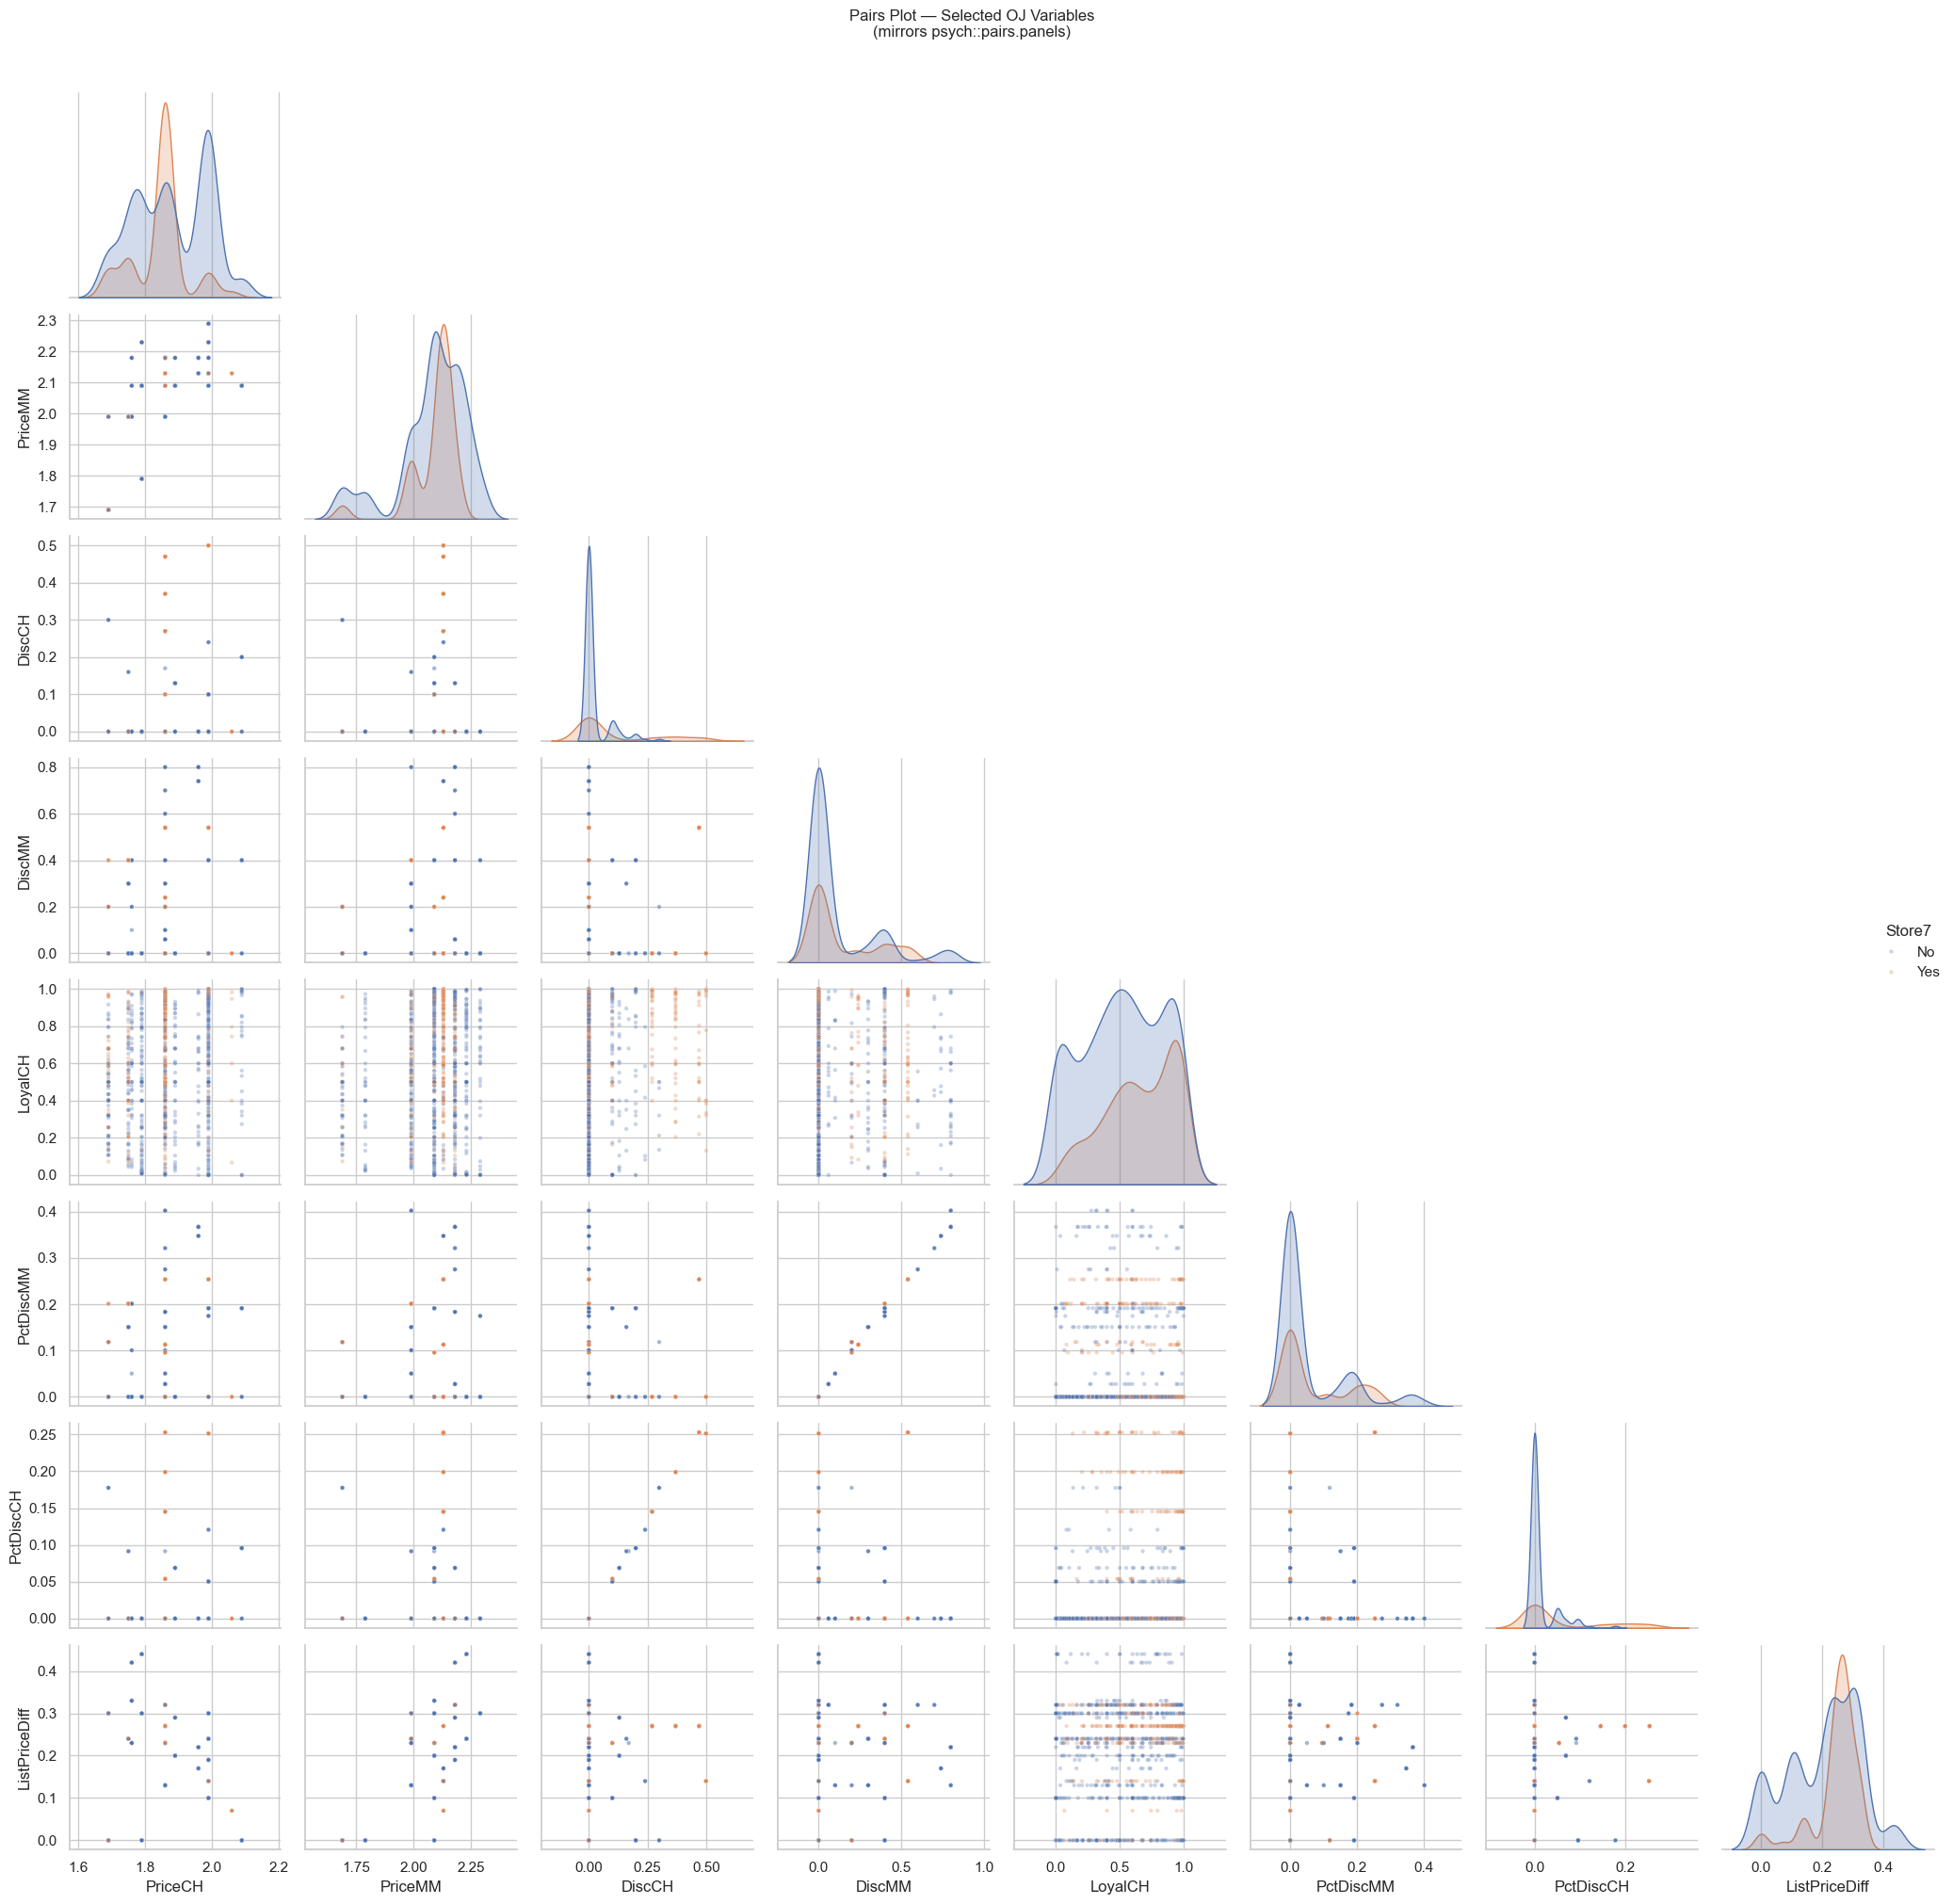

In [5]:
# Select the same variables as the R pairs.panels() call
cols_pairs = ['PriceCH', 'PriceMM', 'DiscCH', 'DiscMM',
              'LoyalCH', 'PctDiscMM', 'PctDiscCH', 'ListPriceDiff']

# Pairplot — mirrors pairs.panels(); hue by Store7 mirrors the color encoding
g = sns.pairplot(OJ[cols_pairs + ['Store7']],
                 hue='Store7',
                 plot_kws={'alpha': 0.3, 's': 10},
                 diag_kind='kde',
                 corner=True)  # corner=True avoids duplicate upper triangle

g.figure.suptitle('Pairs Plot — Selected OJ Variables\n(mirrors psych::pairs.panels)',
                  y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Train / Test Split

Mirrors R:
```r
set.seed(1234)
ind <- sample(2, nrow(OJ), replace=T, prob=c(0.7, 0.3))
train <- OJ[ind==1,]
test  <- OJ[ind==2,]
```

**Note:** R's `sample()` with `replace=T` and `prob=c(0.7, 0.3)` produces a *random* 70/30 split
that does not guarantee exact proportions. Python's `train_test_split` with `test_size=0.3` 
is the clean equivalent. We use `random_state=1234` to mirror `set.seed(1234)`.

In [6]:
# Train/test split — mirrors R set.seed(1234) + sample(2, nrow(OJ), prob=c(0.7,0.3))
train, test = train_test_split(OJ, test_size=0.3, random_state=1234)

# Reset index for clean row numbering
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(f'Train shape: {train.shape}')   # ~749 rows
print(f'Test shape:  {test.shape}')    # ~321 rows

Train shape: (749, 18)
Test shape:  (321, 18)


---

# Example 1: Numeric + Categorical Predictors, With Intercept

## Fit the Model — Train Set

Mirrors R:
```r
m <- lm(PriceCH ~ +PriceMM +WeekofPurchase +DiscCH +Store7 +STORE, train)
summary(m, corr=TRUE)
```

`statsmodels` formula API handles the `Store7` categorical variable automatically.
It creates a single dummy variable `Store7[T.Yes]` (dropping the reference level `No`),
which mirrors R's behavior with a factor variable when the intercept is included.

**Degrees of freedom:**
- $n$ = observations in train dataset
- $p$ = 5 explanatory variables (PriceMM, WeekofPurchase, DiscCH, Store7, STORE)
- Residual DF $= n - p - 1$

In [7]:
# Fit model — mirrors R: lm(PriceCH ~ +PriceMM +WeekofPurchase +DiscCH +Store7 +STORE, train)
# C(Store7) tells statsmodels to treat Store7 as categorical (mirrors R factor)
formula_1 = 'PriceCH ~ PriceMM + WeekofPurchase + DiscCH + C(Store7) + STORE'

m1 = smf.ols(formula=formula_1, data=train).fit()

# Display summary — mirrors R: summary(m, corr=TRUE)
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                PriceCH   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     499.2
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.06e-234
Time:                        09:13:49   Log-Likelihood:                 1198.5
No. Observations:                 749   AIC:                            -2385.
Df Residuals:                     743   BIC:                            -2357.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4288      0.034  

**Notes:**

- `C(Store7)[T.Yes]` is the single dummy variable for `Store7`, reference level = `No`.
  This mirrors R's `Store7Yes` coefficient — only one dummy is needed because
  `Store7No` is simply the complement.
- Residual DF $= n - p - 1$ where $p = 5$ predictors (Store7 counts as 1 even though categorical).

### Diagnostic Plots

Mirrors R: `par(mfrow=c(2,2)); plot(m)`

Four standard OLS diagnostic plots:
1. Residuals vs. Fitted
2. Q-Q plot of standardized residuals
3. Scale-Location (sqrt of standardized residuals vs. fitted)
4. Residuals vs. Leverage (Cook's distance)

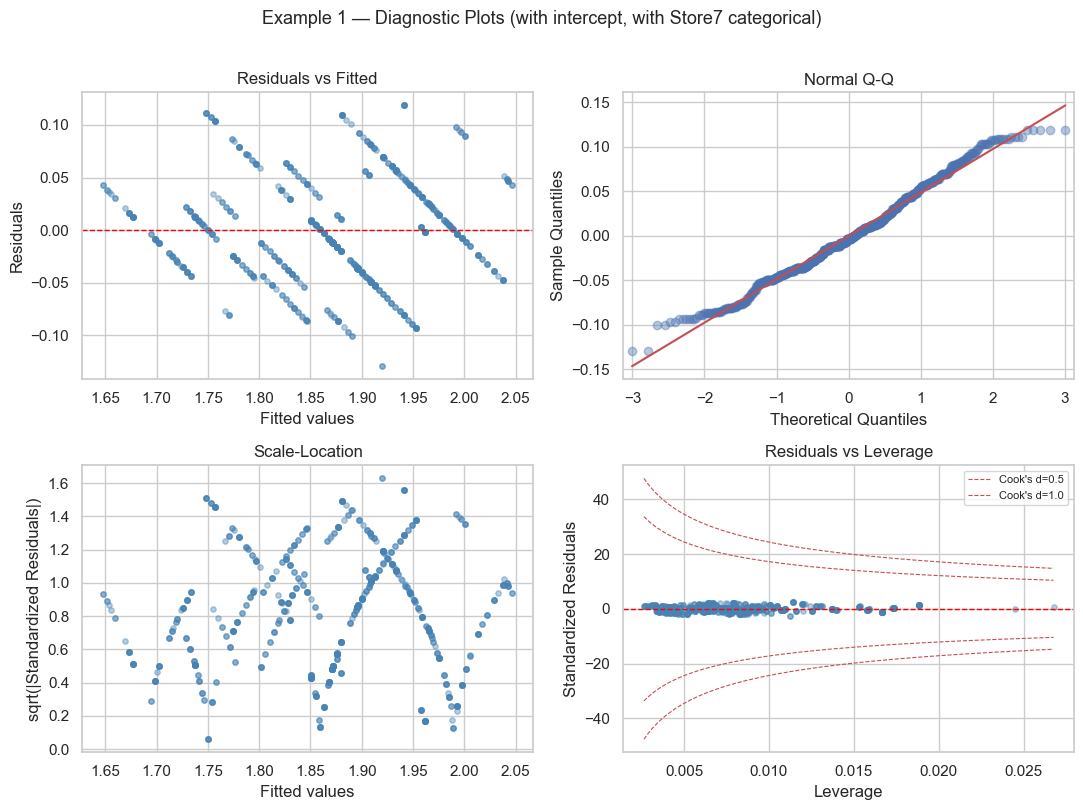

In [8]:
def plot_diagnostics(model, title=''):
    """
    Four-panel OLS diagnostic plot.
    Mirrors R: par(mfrow=c(2,2)); plot(lm_model)

    Parameters
    ----------
    model : statsmodels RegressionResultsWrapper
        A fitted OLS model.
    title : str
        Optional suptitle for the figure.
    """
    fitted    = model.fittedvalues
    residuals = model.resid
    influence = model.get_influence()
    std_resid = influence.resid_studentized_internal
    leverage  = influence.hat_matrix_diag
    cooks_d   = influence.cooks_distance[0]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    # --- Plot 1: Residuals vs. Fitted ---
    axes[0, 0].scatter(fitted, residuals, alpha=0.4, s=15, color='steelblue')
    axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted')

    # --- Plot 2: Q-Q Plot ---
    sm.qqplot(residuals, line='s', ax=axes[0, 1], alpha=0.4)
    axes[0, 1].set_title('Normal Q-Q')

    # --- Plot 3: Scale-Location ---
    axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=15, color='steelblue')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('sqrt(|Standardized Residuals|)')
    axes[1, 0].set_title('Scale-Location')

    # --- Plot 4: Residuals vs. Leverage ---
    axes[1, 1].scatter(leverage, std_resid, alpha=0.4, s=15, color='steelblue')
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Standardized Residuals')
    axes[1, 1].set_title('Residuals vs Leverage')
    # Overlay Cook's distance contours at 0.5 and 1.0
    for cd in [0.5, 1.0]:
        lev_range = np.linspace(leverage.min(), leverage.max(), 200)
        p = model.df_model + 1
        cd_line = np.sqrt(cd * p * (1 - lev_range) / lev_range)
        axes[1, 1].plot(lev_range,  cd_line, 'r--', linewidth=0.8, label=f"Cook's d={cd}")
        axes[1, 1].plot(lev_range, -cd_line, 'r--', linewidth=0.8)
    axes[1, 1].legend(fontsize=8)

    if title:
        fig.suptitle(title, fontsize=13, y=1.01)

    plt.tight_layout()
    plt.show()


# Diagnostic plots for Example 1
plot_diagnostics(m1, title='Example 1 — Diagnostic Plots (with intercept, with Store7 categorical)')

### ANOVA Table

Mirrors R: `anova(m)`

Compare the `Pr(>F)` values here with the p-values in the model summary above — they should be comparable.

In [9]:
# ANOVA table — mirrors R: anova(m)
# typ=1 is sequential (Type I) SS, matching R's default anova()
anova_table_1 = anova_lm(m1, typ=1)
print('ANOVA Table — Example 1')
print(anova_table_1.round(6))

ANOVA Table — Example 1
                   df    sum_sq   mean_sq            F    PR(>F)
C(Store7)         1.0  0.221020  0.221020    91.899185  0.000000
PriceMM           1.0  3.116965  3.116965  1296.022856  0.000000
WeekofPurchase    1.0  1.549317  1.549317   644.200620  0.000000
DiscCH            1.0  0.000057  0.000057     0.023850  0.877309
STORE             1.0  1.115198  1.115198   463.695149  0.000000
Residual        743.0  1.786932  0.002405          NaN       NaN


### Predict on Test Dataset

In [10]:
# Predict on test set — mirrors R: p <- predict(m, test)
p1 = m1.predict(test)

print(f'Predictions shape: {p1.shape}')
print(f'First 5 predictions: {p1.values[:5].round(4)}')

Predictions shape: (321,)
First 5 predictions: [1.7118 1.7635 1.8713 1.836  1.8591]


### Plot: Predictions vs. Actuals

Mirrors R: `ggplot(aes(x=PriceCH, y=p)) + geom_point() + geom_smooth(method='lm', col='red')`

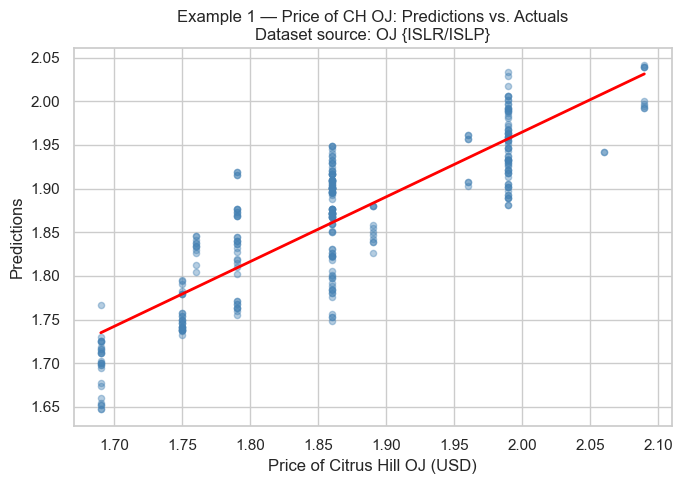

In [11]:
def plot_predictions(y_actual, y_pred, title='', subtitle='Dataset source: OJ {ISLR/ISLP}',
                     xlabel='Price of Citrus Hill OJ (USD)', ylabel='Predictions'):
    """
    Scatter plot of actual vs. predicted values with regression line.
    Mirrors R: ggplot + geom_point + geom_smooth(method='lm', col='red')

    Parameters
    ----------
    y_actual : array-like
    y_pred   : array-like
    title    : str
    subtitle : str
    xlabel   : str
    ylabel   : str
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(y_actual, y_pred, alpha=0.4, s=20, color='steelblue')

    # Regression line — mirrors geom_smooth(method='lm', col='red', se=FALSE)
    m_fit = np.polyfit(y_actual, y_pred, 1)
    x_line = np.linspace(y_actual.min(), y_actual.max(), 100)
    ax.plot(x_line, np.polyval(m_fit, x_line), color='red', linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    full_title = f'{title}\n{subtitle}' if subtitle else title
    ax.set_title(full_title)
    plt.tight_layout()
    plt.show()


# Plot for Example 1
plot_predictions(test['PriceCH'], p1,
                 title='Example 1 — Price of CH OJ: Predictions vs. Actuals')

### Performance: RMSE and R²

Mirrors R:
```r
sqrt(mean((test$PriceCH - p)^2))  # RMSE
cor(test$PriceCH, p)^2            # R-squared
```

In [12]:
# Performance metrics — mirrors R RMSE and R-squared
rmse_1 = root_mean_squared_error(test['PriceCH'], p1)
r2_1   = r2_score(test['PriceCH'], p1)

print(f'Example 1 — With intercept, with Store7 categorical')
print(f'  RMSE : {rmse_1:.6f}')
print(f'  R²   : {r2_1:.6f}')

Example 1 — With intercept, with Store7 categorical
  RMSE : 0.052606
  R²   : 0.732493


---

## Model Attributes and Diagnostics

This section demonstrates how to extract model information from a fitted statsmodels OLS model.
Mirrors R's `attributes(m)`, `m$coefficients`, `attributes(summary_m)`, `summary_m$df`,
`sqrt(diag(vcov(m)))`, `confint(m)`.

### Coefficients

Mirrors R: `m$coefficients`

In [13]:
# Coefficients — mirrors R: m$coefficients
print('Coefficients:')
print(m1.params.round(6))

Coefficients:
Intercept           0.428804
C(Store7)[T.Yes]    0.068296
PriceMM             0.146477
WeekofPurchase      0.004073
DiscCH             -0.033233
STORE               0.046593
dtype: float64


### Degrees of Freedom

Mirrors R: `summary_m$df`

R returns three values: (p+1, residual DF, p+1). Here we show the model and residual DF.

Residual DF $= n - p - 1$ (with intercept)

In [14]:
# Degrees of freedom — mirrors R: summary_m$df
n_train   = int(m1.nobs)
df_model  = int(m1.df_model)   # p (number of predictors, excl. intercept)
df_resid  = int(m1.df_resid)   # n - p - 1

print(f'n (train observations) : {n_train}')
print(f'df_model (p)           : {df_model}   [number of predictors]')
print(f'df_resid (n - p - 1)   : {df_resid}   [residual degrees of freedom]')
print(f'Check: {n_train} - {df_model} - 1 = {n_train - df_model - 1}')

n (train observations) : 749
df_model (p)           : 5   [number of predictors]
df_resid (n - p - 1)   : 743   [residual degrees of freedom]
Check: 749 - 5 - 1 = 743


### Standard Errors of Coefficients

Mirrors R: `sqrt(diag(vcov(m)))`

Extracts the standard error of each individual regression coefficient from the variance-covariance matrix.

In [15]:
# Standard errors — mirrors R: sqrt(diag(vcov(m)))
# statsmodels stores bse directly; we also verify via vcov
se_from_bse  = m1.bse
se_from_vcov = np.sqrt(np.diag(m1.cov_params()))

print('Standard Errors (from bse):')
print(se_from_bse.round(6))
print()
print('Standard Errors (from sqrt(diag(vcov)) — should match):')
print(pd.Series(se_from_vcov, index=m1.params.index).round(6))

Standard Errors (from bse):
Intercept           0.033716
C(Store7)[T.Yes]    0.006743
PriceMM             0.017313
WeekofPurchase      0.000157
DiscCH              0.017332
STORE               0.002164
dtype: float64

Standard Errors (from sqrt(diag(vcov)) — should match):
Intercept           0.033716
C(Store7)[T.Yes]    0.006743
PriceMM             0.017313
WeekofPurchase      0.000157
DiscCH              0.017332
STORE               0.002164
dtype: float64


### Confidence Intervals

Mirrors R: `ci_m <- confint(m); ci_m`

95% confidence intervals for each coefficient. Good to verify none cross zero for significant predictors.

In [16]:
# Confidence intervals — mirrors R: confint(m)
ci_m1 = m1.conf_int(alpha=0.05)  # 95% CI
ci_m1.columns = ['2.5%', '97.5%']

print('95% Confidence Intervals:')
print(ci_m1.round(6))

95% Confidence Intervals:
                      2.5%     97.5%
Intercept         0.362614  0.494993
C(Store7)[T.Yes]  0.055059  0.081533
PriceMM           0.112489  0.180465
WeekofPurchase    0.003765  0.004381
DiscCH           -0.067259  0.000793
STORE             0.042345  0.050840


In [17]:
# CI mean for PriceMM (2nd variable) — mirrors R: mean(c(ci_m[2,1], ci_m[2,2]))
# Index 1 = PriceMM (0-indexed: Intercept=0, PriceMM=1)
ci_mu_PriceMM = ci_m1.iloc[1].mean()
print(f'CI mean for PriceMM: {ci_mu_PriceMM:.6f}')
print(f'(Should equal the PriceMM coefficient: {m1.params.iloc[1]:.6f})')

CI mean for PriceMM: 0.068296
(Should equal the PriceMM coefficient: 0.068296)


### t-Distribution 95% Level

Mirrors R: `qt(0.975, 12)`

The t critical value at the 97.5th percentile (for a two-tailed 95% CI) with 12 degrees of freedom.
Reference: DAAG page 171.

In [18]:
# t critical value — mirrors R: qt(0.975, 12)
t_crit = t_dist.ppf(0.975, df=12)
print(f't critical value (df=12, two-tailed 95%): {t_crit:.6f}')

t critical value (df=12, two-tailed 95%): 2.178813


---

# Example 2: Numeric + Categorical Predictors, Without Intercept

## Fit the Model Without Intercept — Train Set

Mirrors R:
```r
m_noi <- lm(PriceCH ~ -1 +PriceMM +WeekofPurchase +DiscCH +Store7 +STORE, train)
summary(m_noi)
```

**Key observation (mirrors R behavior):**
When the intercept is removed (`-1` in R, `- 1` in statsmodels formula),
the categorical variable `Store7` expands into **two** dummy variables
(`Store7[No]` and `Store7[Yes]`) instead of one. This is because without
an intercept, there is no reference level to drop — both levels are needed
for full rank identification.

In [19]:
# No-intercept model — mirrors R: lm(PriceCH ~ -1 +PriceMM +WeekofPurchase +DiscCH +Store7 +STORE, train)
# '- 1' removes the intercept in statsmodels formula API
formula_2 = 'PriceCH ~ PriceMM + WeekofPurchase + DiscCH + C(Store7) + STORE - 1'

m2 = smf.ols(formula=formula_2, data=train).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                PriceCH   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     499.2
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.06e-234
Time:                        09:13:49   Log-Likelihood:                 1198.5
No. Observations:                 749   AIC:                            -2385.
Df Residuals:                     743   BIC:                            -2357.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
C(Store7)[No]      0.4288      0.034     12.

**Note:** Without intercept, `C(Store7)` produces two dummies: `C(Store7)[No]` and `C(Store7)[Yes]`.
This mirrors R's behavior: `Store7No` and `Store7Yes` both appear in the no-intercept model.

### Diagnostic Plots

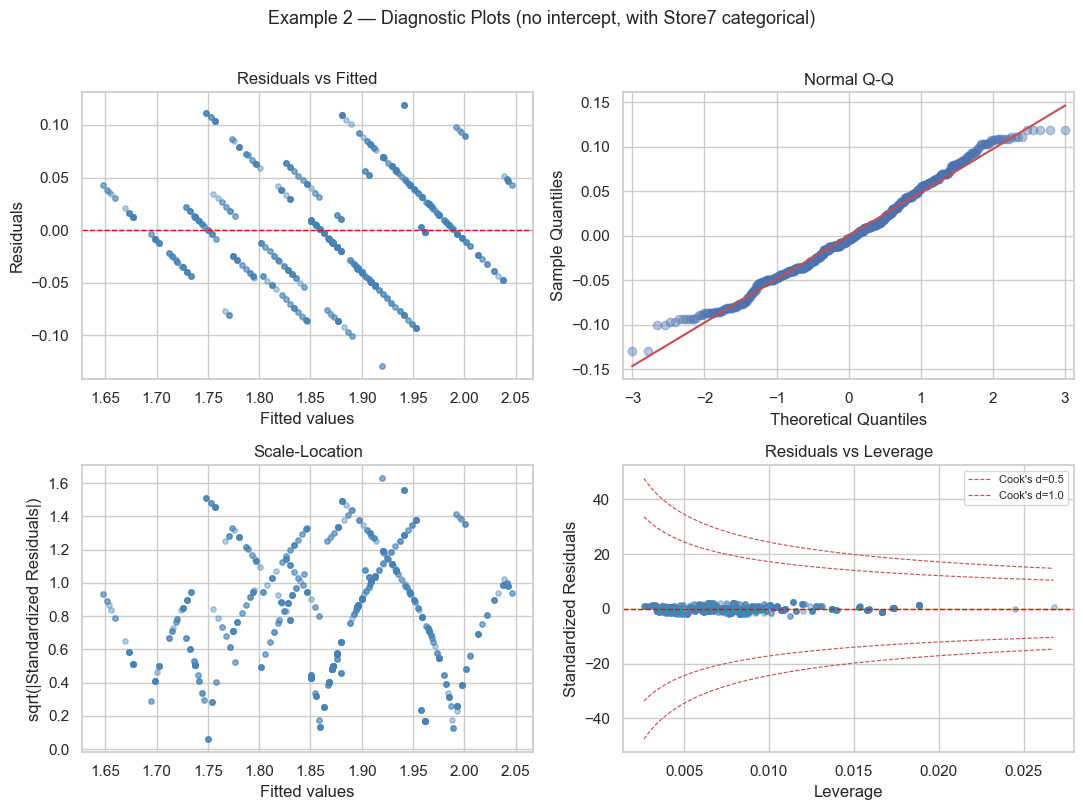

In [20]:
plot_diagnostics(m2, title='Example 2 — Diagnostic Plots (no intercept, with Store7 categorical)')

### Predict on Test Dataset and Plot

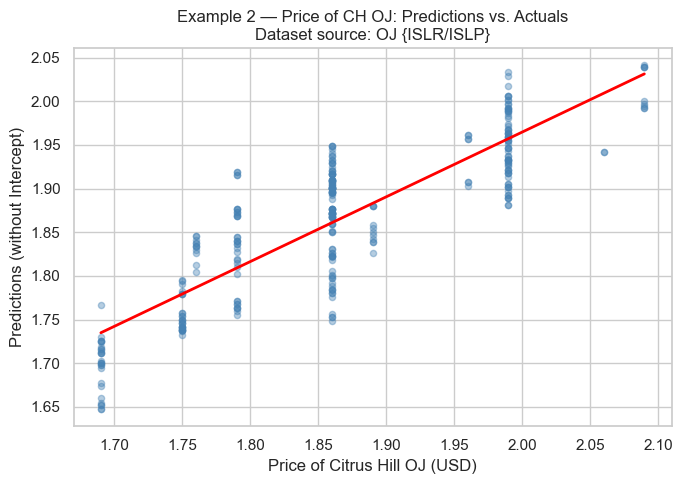

In [21]:
# Predict — mirrors R: p_noi <- predict(m_noi, test)
p2 = m2.predict(test)

# Plot
plot_predictions(test['PriceCH'], p2,
                 title='Example 2 — Price of CH OJ: Predictions vs. Actuals',
                 ylabel='Predictions (without Intercept)')

### Performance: RMSE and R²

In [22]:
rmse_2 = root_mean_squared_error(test['PriceCH'], p2)
r2_2   = r2_score(test['PriceCH'], p2)

print(f'Example 2 — No intercept, with Store7 categorical')
print(f'  RMSE : {rmse_2:.6f}')
print(f'  R²   : {r2_2:.6f}')
print()
print('Compare with Example 1:')
print(f'  Example 1 RMSE: {rmse_1:.6f}   R²: {r2_1:.6f}')
print(f'  Example 2 RMSE: {rmse_2:.6f}   R²: {r2_2:.6f}')

Example 2 — No intercept, with Store7 categorical
  RMSE : 0.052606
  R²   : 0.732493

Compare with Example 1:
  Example 1 RMSE: 0.052606   R²: 0.732493
  Example 2 RMSE: 0.052606   R²: 0.732493


---

# Example 3: Numeric Predictors Only, With Intercept

## Fit the Model — Train Set

Mirrors R:
```r
m <- lm(PriceCH ~ +PriceMM +WeekofPurchase +STORE, train)
summary(m, corr=TRUE)
```

Three numeric predictors only — no categorical `Store7`.

**Degrees of freedom:**
- $p = 3$ explanatory variables
- Residual DF $= n - p - 1 = n - 3 - 1$

In [23]:
# Numeric-only model — mirrors R: lm(PriceCH ~ +PriceMM +WeekofPurchase +STORE, train)
formula_3 = 'PriceCH ~ PriceMM + WeekofPurchase + STORE'

m3 = smf.ols(formula=formula_3, data=train).fit()

print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                PriceCH   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     701.8
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.57e-216
Time:                        09:13:49   Log-Likelihood:                 1149.7
No. Observations:                 749   AIC:                            -2291.
Df Residuals:                     745   BIC:                            -2273.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4523      0.034     13.

In [24]:
# Verify degrees of freedom
n3       = int(m3.nobs)
df_mod3  = int(m3.df_model)
df_res3  = int(m3.df_resid)

print(f'n (train): {n3}')
print(f'p (predictors): {df_mod3}')
print(f'Residual DF = n - p - 1 = {n3} - {df_mod3} - 1 = {df_res3}')

n (train): 749
p (predictors): 3
Residual DF = n - p - 1 = 749 - 3 - 1 = 745


### Diagnostic Plots

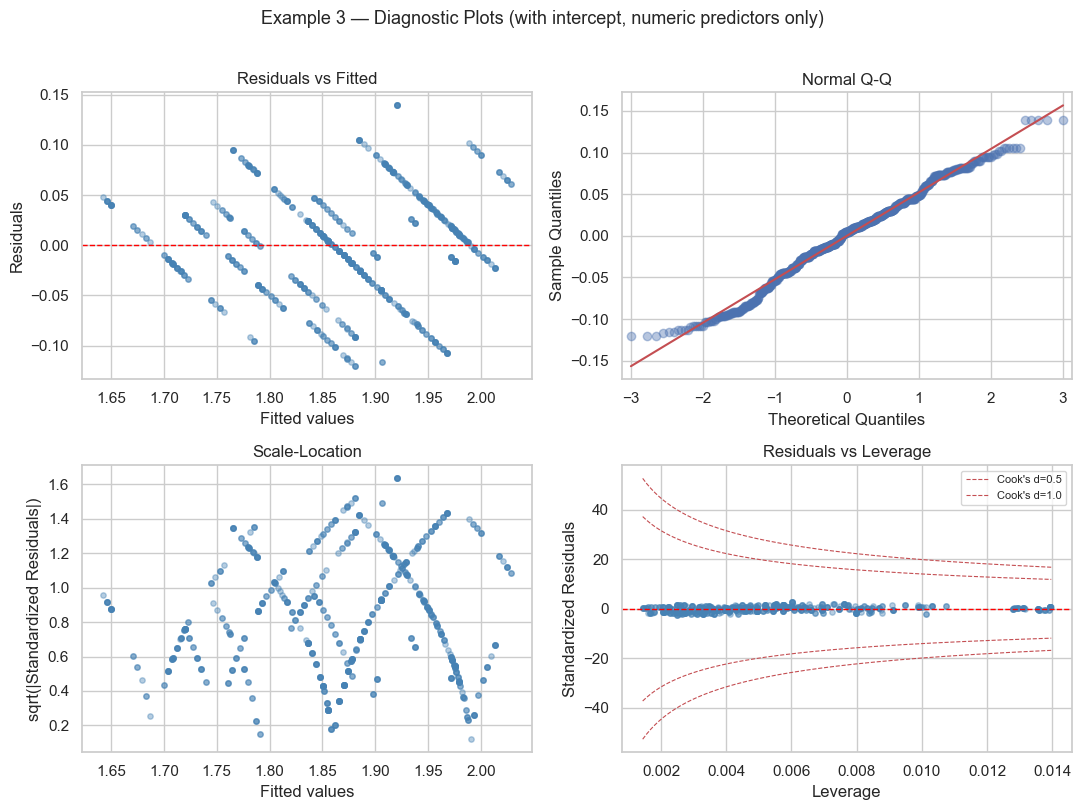

In [25]:
plot_diagnostics(m3, title='Example 3 — Diagnostic Plots (with intercept, numeric predictors only)')

### ANOVA Table

In [26]:
# ANOVA table — mirrors R: anova(m)
anova_table_3 = anova_lm(m3, typ=1)
print('ANOVA Table — Example 3')
print(anova_table_3.round(6))

ANOVA Table — Example 3
                   df    sum_sq   mean_sq            F  PR(>F)
PriceMM           1.0  3.086886  3.086886  1129.604151     0.0
WeekofPurchase    1.0  1.419193  1.419193   519.334396     0.0
STORE             1.0  1.247539  1.247539   456.519863     0.0
Residual        745.0  2.035872  0.002733          NaN     NaN


### Predict on Test Dataset and Plot

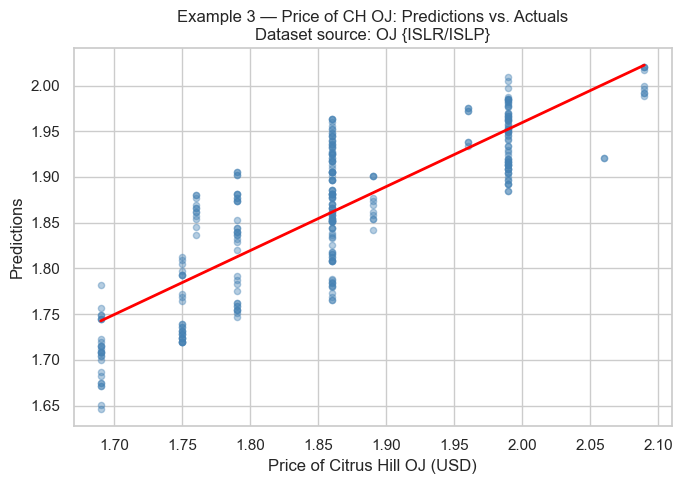

In [27]:
p3 = m3.predict(test)

plot_predictions(test['PriceCH'], p3,
                 title='Example 3 — Price of CH OJ: Predictions vs. Actuals')

### Performance: RMSE and R²

In [28]:
rmse_3 = root_mean_squared_error(test['PriceCH'], p3)
r2_3   = r2_score(test['PriceCH'], p3)

print(f'Example 3 — With intercept, numeric predictors only')
print(f'  RMSE : {rmse_3:.6f}')
print(f'  R²   : {r2_3:.6f}')

Example 3 — With intercept, numeric predictors only
  RMSE : 0.057176
  R²   : 0.683992


---

# Example 4: Numeric Predictors Only, Without Intercept

## Fit the Model Without Intercept — Train Set

Mirrors R:
```r
m_noi <- lm(PriceCH ~ -1 +PriceMM +WeekofPurchase +STORE, train)
summary(m_noi, corr=TRUE)
```

Without intercept and with only numeric predictors:
- Residual DF $= n - p$ (no intercept term to subtract)
- $= n - 3$

In [29]:
# No-intercept, numeric-only model
# mirrors R: lm(PriceCH ~ -1 +PriceMM +WeekofPurchase +STORE, train)
formula_4 = 'PriceCH ~ PriceMM + WeekofPurchase + STORE - 1'

m4 = smf.ols(formula=formula_4, data=train).fit()

print(m4.summary())

                                 OLS Regression Results                                
Dep. Variable:                PriceCH   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          2.598e+05
Date:                Fri, 03 Apr 2026   Prob (F-statistic):                        0.00
Time:                        09:13:49   Log-Likelihood:                          1071.5
No. Observations:                 749   AIC:                                     -2137.
Df Residuals:                     746   BIC:                                     -2123.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [30]:
# Verify degrees of freedom — no intercept: DF = n - p
n4      = int(m4.nobs)
df_mod4 = int(m4.df_model)
df_res4 = int(m4.df_resid)

print(f'n (train): {n4}')
print(f'p (predictors): {df_mod4}')
print(f'Residual DF = n - p = {n4} - {df_mod4} = {df_res4}   (no intercept)')

n (train): 749
p (predictors): 3
Residual DF = n - p = 749 - 3 = 746   (no intercept)


### Diagnostic Plots

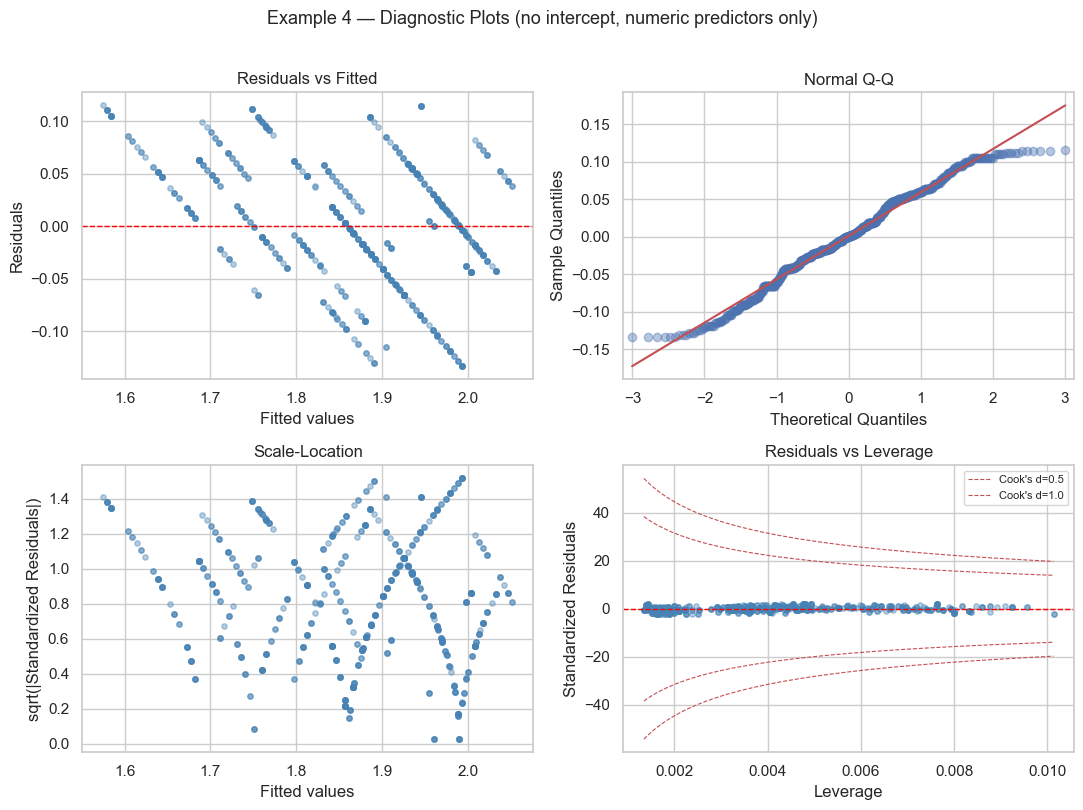

In [31]:
plot_diagnostics(m4, title='Example 4 — Diagnostic Plots (no intercept, numeric predictors only)')

### Predict on Test Dataset and Plot

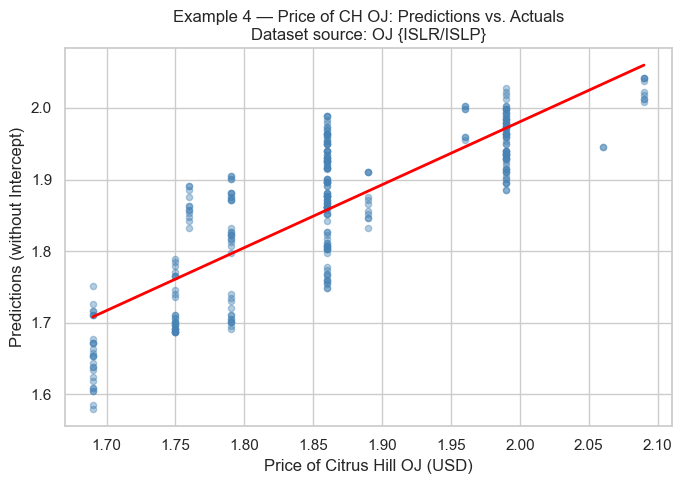

In [32]:
p4 = m4.predict(test)

plot_predictions(test['PriceCH'], p4,
                 title='Example 4 — Price of CH OJ: Predictions vs. Actuals',
                 ylabel='Predictions (without Intercept)')

### Performance: RMSE and R²

In [33]:
rmse_4 = root_mean_squared_error(test['PriceCH'], p4)
r2_4   = r2_score(test['PriceCH'], p4)

print(f'Example 4 — No intercept, numeric predictors only')
print(f'  RMSE : {rmse_4:.6f}')
print(f'  R²   : {r2_4:.6f}')

Example 4 — No intercept, numeric predictors only
  RMSE : 0.063449
  R²   : 0.610846


---

# Summary and Conclusions

## Model Comparison

In [34]:
# Summary comparison table
summary_df = pd.DataFrame({
    'Example': ['Ex 1', 'Ex 2', 'Ex 3', 'Ex 4'],
    'Predictors'  : ['PriceMM, WeekofPurchase, DiscCH, Store7, STORE'] * 2 +
                    ['PriceMM, WeekofPurchase, STORE'] * 2,
    'Intercept'   : ['Yes', 'No', 'Yes', 'No'],
    'Categorical' : ['Store7 (Yes/No)', 'Store7 (Yes/No)', 'None', 'None'],
    'RMSE'        : [rmse_1, rmse_2, rmse_3, rmse_4],
    'R²'          : [r2_1,   r2_2,   r2_3,   r2_4]
})

print(summary_df.to_string(index=False))

Example                                     Predictors Intercept     Categorical     RMSE       R²
   Ex 1 PriceMM, WeekofPurchase, DiscCH, Store7, STORE       Yes Store7 (Yes/No) 0.052606 0.732493
   Ex 2 PriceMM, WeekofPurchase, DiscCH, Store7, STORE        No Store7 (Yes/No) 0.052606 0.732493
   Ex 3                 PriceMM, WeekofPurchase, STORE       Yes            None 0.057176 0.683992
   Ex 4                 PriceMM, WeekofPurchase, STORE        No            None 0.063449 0.610846


## Key Takeaways

1. **Categorical variables:** When the intercept is included, `Store7` produces a single dummy
   variable (reference level dropped). Without intercept, both levels appear as separate dummies.
   This mirrors R's behavior exactly.

2. **Intercept vs. no intercept:** Performance metrics (RMSE, R²) are comparable across
   with/without intercept configurations, as noted in the original R analysis.

3. **Degrees of freedom:**
   - With intercept: $DF_{resid} = n - p - 1$
   - Without intercept: $DF_{resid} = n - p$

4. **R → Python mapping:**
   - `lm()` → `statsmodels.formula.api.ols()`
   - `summary(m)` → `m.summary()`
   - `anova(m)` → `statsmodels.stats.anova.anova_lm(m, typ=1)`
   - `predict(m, test)` → `m.predict(test)`
   - `confint(m)` → `m.conf_int()`
   - `sqrt(diag(vcov(m)))` → `m.bse` or `np.sqrt(np.diag(m.cov_params()))`
   - `qt(0.975, df)` → `scipy.stats.t.ppf(0.975, df=df)`
   - `ggplot + geom_point + geom_smooth` → `matplotlib + seaborn`
   - `pairs.panels()` → `seaborn.pairplot()`

## References

1. Harvard STAT 109, 2023. Weekly slides by Dr. Bharatendra Rai.
2. Dr. Bharatendra Rai. YouTube channel. https://youtu.be/cW59Yh_GfNk
3. John Maindonald and W. John Braun. *Data Analysis and Graphics Using R*. Cambridge. Third Ed. ISBN 978-0-521-76293-9.
4. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
5. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com